In [ ]:
import shutil
import os

archive_base_name = '/content/colab_notebook'
file_to_archive_path = '/content/ipl_data_py.py'
file_to_archive_name = os.path.basename(file_to_archive_path)
parent_directory = os.path.dirname(file_to_archive_path)

# Ensure the parent directory exists
os.makedirs(parent_directory, exist_ok=True)

# Check if the file to be archived exists. If not, create an empty one as a placeholder.
if not os.path.exists(file_to_archive_path):
    print(f"Warning: The file '{file_to_archive_path}' was not found. Creating an empty placeholder file for archiving.")
    with open(file_to_archive_path, 'w') as f:
        f.write("# This is a placeholder file. Please add your Python code here if you intend to archive a script.\n")

# Archive the file by specifying its parent directory as the root_dir
# and the file itself as the base_dir to include only that file at the root of the zip.
shutil.make_archive(archive_base_name, 'zip', parent_directory, base_dir=file_to_archive_name)
print(f"Archive '{archive_base_name}.zip' created containing '{file_to_archive_name}'.")

Archive '/content/colab_notebook.zip' created containing 'ipl_data_py.py'.


In [ ]:
from google.colab import files
files.download('/content/colab_notebook.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import keras
import tensorflow as tf

In [ ]:
ipl = pd.read_csv('/content/ipl_data (1).csv')
ipl.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/ipl_data (1).csv'

In [ ]:
#Dropping certain features
df = ipl.drop(['date', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5','mid', 'striker', 'non-striker'], axis =1)

KeyError: "['date', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'mid', 'striker', 'non-striker'] not found in axis"

In [ ]:
X = df.drop(['total'], axis =1)
y = df['total']

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object for each categorical feature
venue_encoder = LabelEncoder()
batting_team_encoder = LabelEncoder()
bowling_team_encoder = LabelEncoder()
striker_encoder = LabelEncoder()
bowler_encoder = LabelEncoder()

# Fit and transform the categorical features with label encoding
X['venue'] = venue_encoder.fit_transform(X['venue'])
X['bat_team'] = batting_team_encoder.fit_transform(X['bat_team'])
X['bowl_team'] = bowling_team_encoder.fit_transform(X['bowl_team'])
X['batsman'] = striker_encoder.fit_transform(X['batsman'])
X['bowler'] = bowler_encoder.fit_transform(X['bowler'])

In [ ]:
# Train test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Define the neural network model
model = keras.Sequential([
    keras.layers.Input( shape=(X_train_scaled.shape[1],)),  # Input layer
    keras.layers.Dense(512, activation='relu'),  # Hidden layer with 512 units and ReLU activation
    keras.layers.Dense(216, activation='relu'),  # Hidden layer with 216 units and ReLU activation
    keras.layers.Dense(1, activation='linear')  # Output layer with linear activation for regression
])

# Compile the model with Huber loss
huber_loss = tf.keras.losses.Huber(delta=1.0)  # You can adjust the 'delta' parameter as needed
model.compile(optimizer='adam', loss=huber_loss)  # Use Huber loss for regression

In [ ]:
# Train the model
model.fit(X_train_scaled, y_train, epochs=50, batch_size=64, validation_data=(X_test_scaled, y_test))

Epoch 1/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 56.3969 - val_loss: 22.1166
Epoch 2/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 22.4076 - val_loss: 22.0121
Epoch 3/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 22.1667 - val_loss: 21.9615
Epoch 4/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 22.3354 - val_loss: 22.0547
Epoch 5/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 22.0421 - val_loss: 22.0360
Epoch 6/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 22.2234 - val_loss: 21.9470
Epoch 7/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 22.0351 - val_loss: 21.9527
Epoch 8/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 22.0587 - val_loss: 21.8486
Epoch 9/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 22.0804 - val_loss: 21.7772
Epoch 10/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 22.1715 - val_loss: 21.7540
Epoch 11/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 22.2379 - val_loss: 21.7425
Epoch 12/50
832/832 ━━━━━━━

<Axes: >

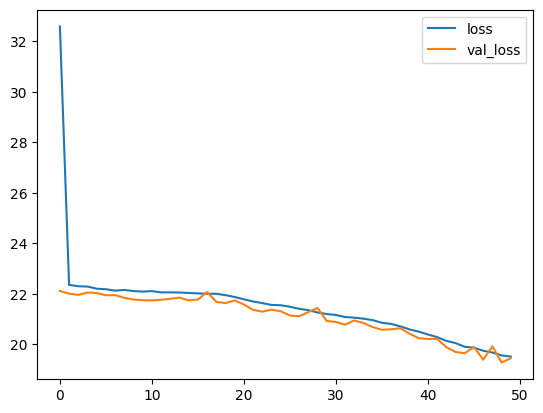

In [ ]:
model_losses = pd.DataFrame(model.history.history)
model_losses.plot()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


Mean Absolute Error (MAE): 19.949670111069263
Root Mean Squared Error (RMSE): 26.9796895268642


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# Define dropdowns
venue = widgets.Dropdown(options=df['venue'].unique().tolist(), description='Select Venue:')
batting_team = widgets.Dropdown(options=df['bat_team'].unique().tolist(), description='Select Batting Team:')
bowling_team = widgets.Dropdown(options=df['bowl_team'].unique().tolist(), description='Select Bowling Team:')
striker = widgets.Dropdown(options=df['batsman'].unique().tolist(), description='Select Striker:')
bowler = widgets.Dropdown(options=df['bowler'].unique().tolist(), description='Select Bowler:')
predict_button = widgets.Button(description="Predict Score")
output = widgets.Output()

# Define prediction function
def predict_score(b):
    with output:
        clear_output()  # Clear the previous output

        # Decode the selected values back to their encoded form
        decoded_venue = venue_encoder.transform([venue.value])
        decoded_batting_team = batting_team_encoder.transform([batting_team.value])
        decoded_bowling_team = bowling_team_encoder.transform([bowling_team.value])
        decoded_striker = striker_encoder.transform([striker.value])
        decoded_bowler = bowler_encoder.transform([bowler.value])

        # Prepare input for model
        input_data = np.array([decoded_venue, decoded_batting_team, decoded_bowling_team, decoded_striker, decoded_bowler])
        input_data = input_data.reshape(1, -1)
        input_data = scaler.transform(input_data)

        # Predict the score
        predicted_score = model.predict(input_data)
        predicted_score = int(predicted_score[0, 0])

        # Display the prediction
        print(f"Predicted Score: {predicted_score}")

# Attach the function to the button click event
predict_button.on_click(predict_score)

# Display widgets
display(venue, batting_team, bowling_team, striker, bowler, predict_button, output)


Dropdown(description='Select Venue:', options=('M Chinnaswamy Stadium', 'Punjab Cricket Association Stadium, M…

Dropdown(description='Select Batting Team:', options=('Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasth…

Dropdown(description='Select Bowling Team:', options=('Royal Challengers Bangalore', 'Kings XI Punjab', 'Delhi…

Dropdown(description='Select Striker:', options=('SC Ganguly', 'BB McCullum', 'RT Ponting', 'DJ Hussey', 'Moha…

Dropdown(description='Select Bowler:', options=('P Kumar', 'Z Khan', 'AA Noffke', 'JH Kallis', 'SB Joshi', 'CL…

Button(description='Predict Score', style=ButtonStyle())

Output()